In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/MARTINI/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue',  'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [2]:
temp = np.genfromtxt((work_dir + 'polystat/0.xvg'), usecols=(2), skip_header=28, unpack=True)
rg_array = np.zeros((len(temp), 32))

for nr in range(0, 32, 1):
    temp = np.genfromtxt((work_dir + 'polystat/' + str(nr) + '.xvg'), usecols=(2), skip_header=28, unpack=True)
    rg_array[:, nr] = temp
print(rg_array)

[[1.1098 1.1085 1.3274 ... 1.2294 1.2716 1.1123]
 [1.1144 1.1393 1.2532 ... 1.1789 1.1045 1.1711]
 [1.1018 1.1261 1.2932 ... 1.1068 1.3733 1.1931]
 ...
 [1.1695 1.7897 1.6149 ... 1.5167 1.239  1.4977]
 [1.308  1.792  1.6407 ... 1.5574 1.2687 1.4853]
 [1.3497 1.7633 1.6132 ... 1.3575 1.261  1.4481]]


In [3]:
pairs = list(combinations(range(0, 32, 1), 2))
t, temp = np.genfromtxt((work_dir + 'pairdist/Chain0/0_0.xvg'), usecols=(0, 1), skip_header=24, unpack=True)
dist_array = np.zeros((len(temp), len(pairs)))

counter = 0
for pair in pairs:
    temp = np.genfromtxt((work_dir + 'pairdist/Chain' + str(pair[0]) + '/' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                         usecols=(1), skip_header=24, unpack=True)
    dist_array[:, counter] = temp
    counter += 1
print(dist_array)

[[13.972 10.251  4.121 ... 10.132  2.925 13.149]
 [14.644  9.386  4.533 ...  9.95   3.596 13.006]
 [14.137  9.969  3.735 ...  9.878  3.152 12.24 ]
 ...
 [ 1.533  2.778  4.688 ...  0.343  3.961  2.771]
 [ 1.353  2.936  5.133 ...  0.405  4.06   2.693]
 [ 1.171  2.336  4.809 ...  0.328  4.292  2.94 ]]


In [4]:
asso_list = []
asso_array = np.zeros_like(dist_array)
x = np.expand_dims((np.arange(0, len(pairs))), axis=1)
y = np.expand_dims(t, axis=0)
X, Y = np.meshgrid(x, y)

for (dist_entry, rg_entry, asso_entry) in zip(dist_array, rg_array, asso_array):
    asso_count = 0
    counter = 0
    for dist_point in dist_entry:
        temp = pairs[counter]
        cutoff = rg_entry[temp[0]] + rg_entry[temp[1]]
        if dist_point <= cutoff:
            asso_count += 1
            asso_entry[counter] += 1
        counter += 1
    asso_list.append(asso_count)

counter = 0
asso_range = range(np.min(asso_list), np.max(asso_list), 1)
asso_count = np.zeros_like(asso_range)
for point in asso_range:
    for element in asso_list:
        if element == point:
            asso_count[counter] += 1
    counter += 1

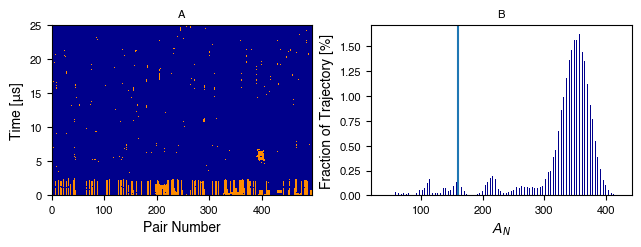

In [20]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), constrained_layout=True)
ax[0].contourf(X[::10], (Y[::10]*(10**-6)), asso_array[::10], levels=1, colors=[color_list[-1], color_list[0]])
ax[0].set_ylim(0, 25)
ax[0].tick_params(labelsize=font)
ax[0].set_xlabel('Pair Number', fontsize=font_label)
ax[0].set_ylabel('Time [μs]', fontsize=font_label)
ax[0].set_title('A', fontsize=font)

ax[1].bar(asso_range, ((asso_count/sum(asso_count))*100), color=color_list[0], width=0.4)
ax[1].tick_params(labelsize=font)
ax[1].set_xlabel('$A_{N}$', fontsize=font_label)
ax[1].set_ylabel('Fraction of Trajectory [%]', fontsize=font_label)
ax[1].set_title('B', fontsize=font)
ax[1].axvline(160)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Hst1_complex_formation.png', dpi=1000)

In [11]:
len(pairs)

496